In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.units import u
from astropy.coordinates import SkyCoord
import sys
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval

pf.housestyle_rcparams()

True

In [8]:
CUBE_PATH = '../../cubes/macs0159m34_COMBINED_CUBE_MED_FINAL.fits'
TITLE = 'MACS'
RADIUS_ARCSEC = .6
Z = 0.249

ra_hms = '01h59m04.03s'
dec_dms = '-34d13m31.8s'
coords = SkyCoord(ra_hms, dec_dms, frame='icrs')
RA_DEG = coords.ra.deg
DEC_DEG = coords.dec.deg

In [15]:
def generate_gaussian_profile(
    gauss_params,
    num_points: int = 500,
    width_factor: float = 4.0
) -> np.ndarray:
    sigma = gauss_params.fwhm / (2 * np.sqrt(2 * np.log(2)))

    x_min = gauss_params.lpeak - width_factor * gauss_params.fwhm / 2
    x_max = gauss_params.lpeak + width_factor * gauss_params.fwhm / 2
    x = np.linspace(x_min, x_max, num_points)

    y = gauss_params.cont + gauss_params.peak * np.exp(
        -((x - gauss_params.lpeak) ** 2) / (2 * sigma ** 2)
    )
    return np.vstack((x, y))

def analyze_galaxy_spectrum(cube_path, ra, dec, radius, z_guess, titlename, pref):
    # 1. Load the Datacube
    print(f'Loading datacube: {cube_path}...')
    try:
        cube = Cube(cube_path)
        print(f'Successfully loaded cube. Dimensions: {cube.shape}')
    except FileNotFoundError:
        print(f'Error: Datacube not found at {cube_path}')
        print('Please ensure the path is correct and you are running this script from the project\'s root directory.')
        sys.exit(1)

    # 2. Extract the 1D Spectrum
    center = (dec, ra)  # (Dec, RA) order for MPDAF
    print(f'\nExtracting spectrum at (RA, Dec) = ({ra:.6f}, {dec:.6f}) with a {radius}" radius aperture.')
    spec = cube.aperture(center, radius, is_sum=True)
    print('Extraction complete.')

    # 3. Plot the Extracted Spectrum
    fig1, ax1 = pf.create_plot(size=(8, 2))
    ax1_cont = fig1.add_axes((1.02, 0, 1/4, 1))
    spec.plot(ax=ax1, title=f'{titlename} at (RA={ra:.4f}, Dec={dec:.4f})', color='#ff004f')
    ax1.set_xlabel(r'Wavelength, $\lambda$, [$\AA$]')
    ax1.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')
    fig1.canvas.manager.set_window_title('Extracted Spectrum')

    # Create and plot a continuum image cutout centered on the object
    print('Creating continuum image cutout...')
    cont_wave_min, cont_wave_max = 7000, 7500  # Angstroms, in observed frame
    subcube_cont = cube.select_lambda(cont_wave_min, cont_wave_max)
    im_cont = subcube_cont.mean(axis=0)

    # Create a cutout (sub-image) centered on the target coordinates
    cutout_size_arcsec = 4.0  # The size of the square cutout in arcseconds
    im_cutout = im_cont.subimage(center=(dec, ra), size=cutout_size_arcsec)

    # Use ZScaleInterval to calculate vmin and vmax for contrast scaling on the cutout
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(im_cutout.data)
    
    im_cutout.plot(ax=ax1_cont, vmin=vmin, vmax=vmax, show_xlabel=False, show_ylabel=False)
    ax1_cont.set_xticks([])
    ax1_cont.set_yticks([])
    
    # Convert world coordinates to pixel coordinates for the cutout to overlay the aperture circle
    center_pix_yx = im_cutout.wcs.sky2pix([dec, ra], 1)[0]  # returns (row, col) ~ (y, x)
    pix_step_arcsec = im_cutout.wcs.get_step()[0]
    radius_pix = radius / pix_step_arcsec

    # Matplotlib's Circle needs (x, y) for the center, so we reverse the order from sky2pix.
    aperture_circle = Circle((center_pix_yx[1], center_pix_yx[0]), radius_pix,
                             edgecolor='white', facecolor='none', lw=1)
    ax1_cont.add_patch(aperture_circle)

    pf.fix_plot([ax1])
    fig1.savefig(f'figs/{titlename}_{pref}_spectra.png', dpi=600, bbox_inches='tight')

    # 4. Measure Spectroscopic Redshift from Emission Lines
    print('\nMeasuring spectroscopic redshift...')
    
    # Define emission lines for redshift measurement (rest-frame wavelengths in Angstroms)
    lines_for_z = {
        'Hbeta': 4861.33,
        'OIII_5007': 5006.84,
        'Halpha': 6562.80,
    }
    
    measured_redshifts = []
    for name, rest_wavelength in lines_for_z.items():
        # Estimate observed wavelength with the initial guess
        obs_wavelength_guess = rest_wavelength * (1 + z_guess)
        
        # Fit the line in the OBSERVED spectrum
        try:
            # Search in a window around the guessed wavelength
            fit = spec.gauss_fit(lmin=(obs_wavelength_guess - 30), lmax=(obs_wavelength_guess + 30), plot=False)
            
            # Calculate redshift from the fitted peak
            measured_lpeak = fit.lpeak
            line_z = (measured_lpeak / rest_wavelength) - 1
            measured_redshifts.append(line_z)
            print(f'  - {name}: Found at {measured_lpeak:.2f} \AA, z = {line_z:.5f}')
        except Exception as e:
            print(f'  - {name}: Fit failed near {obs_wavelength_guess:.2f} \AA.')

    if not measured_redshifts:
        print('\nError: Could not measure redshift from any emission lines. Using initial guess.')
        z_measured = z_guess
    else:
        z_measured = np.mean(measured_redshifts)
        z_std = np.std(measured_redshifts)
        print(f'\nMeasured Redshift z = {z_measured:.5f} \xB1 {z_std:.5f}')

    # 5. De-redshift the spectrum and measure line properties
    # De-redshift the spectrum to the rest frame using the MEASURED redshift
    spec_rest = spec.copy()
    spec_rest.wave.set_crval(spec_rest.wave.get_crval() / (1 + z_measured))
    spec_rest.wave.set_step(spec_rest.wave.get_step() / (1 + z_measured))

    # Define emission lines for analysis (rest-frame wavelengths in Angstroms)
    lines = {
        'Hbeta': 4861.33,
        'OIII_5007': 5006.84,
        'Halpha': 6562.80,
        'NII_6583': 6583.45
    }

    titles = {
        'Hbeta': r'H$\beta$',
        'OIII_5007': r'O$_{\mathrm{III-}5007}$',
        'Halpha': r'H$\alpha$',
        'NII_6583': r'N$_{\mathrm{II-}6583}$'   
    }

    line_fits = {}
    # Fit each line with a Gaussian in the rest-frame spectrum
    for name, wavelength in lines.items():
        try:
            fit = spec_rest.gauss_fit(lmin=(wavelength - 15), lmax=(wavelength + 15), plot=False)
            line_fits[name] = fit
        except:
            line_fits[name] = None

    # Plot the fits for visual inspection
    fig2, axes = plt.subplots(2, 2, figsize=(8, 7.5))
    fig2.canvas.manager.set_window_title('Emission Line Fits')

    for ax, name in zip(axes.ravel(), lines.keys()):
        fit = line_fits.get(name)
        if fit is not None:
            gprofile = generate_gaussian_profile(fit, 500, 100)
            ax.plot(gprofile[0], gprofile[1], color='k', lw=1.4)
            spec_rest.plot(ax=ax, color='#ff004f')
            ax.set_xlim([np.min(gprofile[0]), np.max(gprofile[0])])
            ax.set_title(titles[name])
            ax.set_ylabel(r'Flux [$\times10^{-20}\,\mathrm{erg}/\AA\,s\,\mathrm{cm}^{-2}$]')
            ax.set_xlabel(r'Rest Frame $\lambda$, [$\AA$]')
        else:
            ax.set_title(f'{titles[name]} (Fit Failed)')
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    
    # Calculate OIII/Hbeta ratio and NII/Halpha ratio and add to plot
    oiii_fit = line_fits.get('OIII_5007')
    hbeta_fit = line_fits.get('Hbeta')
    nii_fit = line_fits.get('NII_6583')
    halpha_fit = line_fits.get('Halpha')

    title_lines = [f'Spectroscopic Redshift z = {z_measured:.5f}']
    
    if oiii_fit and hbeta_fit and hbeta_fit.flux > 0:
        oiii_hbeta_ratio = oiii_fit.flux / hbeta_fit.flux
        oiii_hbeta_ratio_error = oiii_hbeta_ratio * np.sqrt((oiii_fit.err_flux / oiii_fit.flux)**2 + (hbeta_fit.err_flux / hbeta_fit.flux)**2)
        log_oiii_hbeta_ratio = np.log10(oiii_hbeta_ratio)
        log_oiii_hbeta_ratio_error = oiii_hbeta_ratio_error / (oiii_hbeta_ratio * np.log(10))
        print(f'[OIII]/H\u03b2 = {oiii_hbeta_ratio:.3f} +/- {oiii_hbeta_ratio_error:.3f}')
        print(f'log([OIII]/H\u03b2) = {log_oiii_hbeta_ratio:.3f} +/- {log_oiii_hbeta_ratio_error:.3f}\n')
        title_lines.append(fr'$\log([\mathrm{{OIII}}] / \mathrm{{H}}\beta) = {log_oiii_hbeta_ratio:.2f} \pm {log_oiii_hbeta_ratio_error:.2f}$')
    else:
        print('[OIII]/Hbeta could not be calculated.\n')
        title_lines.append(r'$\log([\mathrm{OIII}] / \mathrm{H}\beta)$ not calculated')

    if nii_fit and halpha_fit and halpha_fit.flux > 0:
        nii_halpha_ratio = nii_fit.flux / halpha_fit.flux
        nii_halpha_ratio_error = nii_halpha_ratio * np.sqrt((nii_fit.err_flux / nii_fit.flux)**2 + (halpha_fit.err_flux / halpha_fit.flux)**2)
        log_nii_halpha_ratio = np.log10(nii_halpha_ratio)
        log_nii_halpha_ratio_error = nii_halpha_ratio_error / (nii_halpha_ratio * np.log(10))
        print(f'[NII]/H\u03b1 = {nii_halpha_ratio:.3f} +/- {nii_halpha_ratio_error:.3f}')
        print(f'log([NII]/H\u03b1) = {log_nii_halpha_ratio:.3f} +/- {log_nii_halpha_ratio_error:.3f}\n')
        title_lines.append(fr'$\log([\mathrm{{NII}}] / \mathrm{{H}}\alpha) = {log_nii_halpha_ratio:.2f} \pm {log_nii_halpha_ratio_error:.2f}$')
    else:
        print('[NII]/Halpha could not be calculated.\n')
        title_lines.append(r'$\log([\mathrm{NII}] / \mathrm{H}\alpha)$ not calculated')

    fig2.suptitle('\n'.join(title_lines), y=1.0)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    pf.fix_plot(axes.flatten())
    fig2.savefig(f'figs/{titlename}_{pref}_lines.png', dpi=600, bbox_inches='tight')

    return spec, line_fits

<>:97: SyntaxWarning: invalid escape sequence '\A'
<>:99: SyntaxWarning: invalid escape sequence '\A'
<>:97: SyntaxWarning: invalid escape sequence '\A'
<>:99: SyntaxWarning: invalid escape sequence '\A'
/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_57137/3677460525.py:97: SyntaxWarning: invalid escape sequence '\A'
  print(f'  - {name}: Found at {measured_lpeak:.2f} \AA, z = {line_z:.5f}')
/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_57137/3677460525.py:99: SyntaxWarning: invalid escape sequence '\A'
  print(f'  - {name}: Fit failed near {obs_wavelength_guess:.2f} \AA.')


[INFO] 36 spaxels used


Loading datacube: ../../cubes/macs0159m34_COMBINED_CUBE_MED_FINAL.fits...
Successfully loaded cube. Dimensions: (3681, 314, 329)

Extracting spectrum at (RA, Dec) = (29.766792, -34.225500) with a 0.6" radius aperture.
Extraction complete.
Creating continuum image cutout...

Measuring spectroscopic redshift...
  - Hbeta: Found at 6072.99 \AA, z = 0.24925
  - OIII_5007: Found at 6255.22 \AA, z = 0.24934
  - Halpha: Found at 8198.96 \AA, z = 0.24931

Measured Redshift z = 0.24930 ± 0.00004
[OIII]/Hβ = 3.082 +/- 0.473
log([OIII]/Hβ) = 0.489 +/- 0.067

[NII]/Hα = 0.078 +/- 0.026
log([NII]/Hα) = -1.107 +/- 0.146



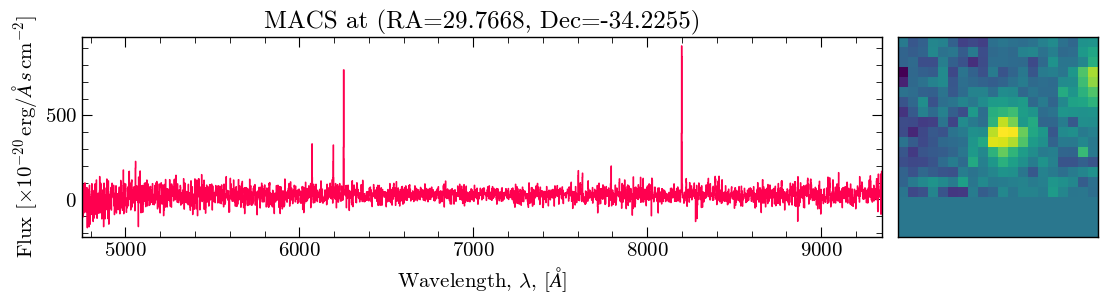

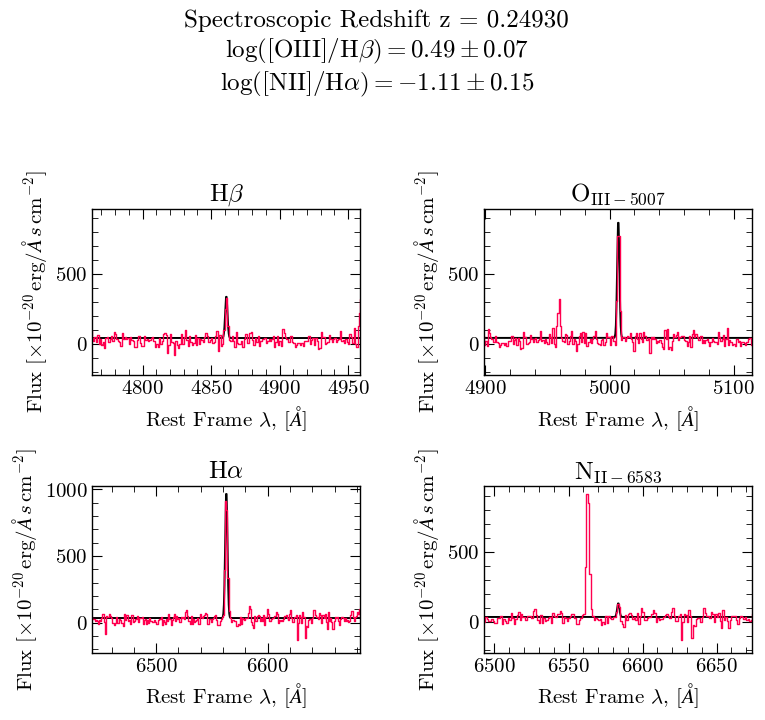

In [16]:
spec, lf1 = analyze_galaxy_spectrum(
    cube_path=CUBE_PATH,
    ra=RA_DEG,
    dec=DEC_DEG,
    radius=RADIUS_ARCSEC,
    titlename=TITLE,
    z_guess=Z,
    pref=ra_hms.replace('.','p')+'_'+dec_dms.replace('.','p')
)